# TP 5 Text Mining:

In [15]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Charger le jeu de données Excel
Charger le jeu de données dans un dataFrame `pandas` et explorer les colonnes (on s'attend à avoir les colonnes `category` et `text`).

In [16]:
dataset_path = 'TP5 dataset Travail a faire Kmeans .xlsx'
df = pd.read_excel(dataset_path)

display(df.head())

print(df.info())

print("\nCategory Distribution:")
print(df['category'].value_counts())

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB
None

Category Distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


## 2. Vectorisation du texte

In [17]:
vectorizer = TfidfVectorizer(stop_words='english')

X_text = df['text'].fillna('')
X = vectorizer.fit_transform(X_text)

print(f"Shape of TF-IDF matrix: {X.shape}")

Shape of TF-IDF matrix: (2225, 29126)


## 3. Application du clustering K-Means

In [18]:
true_labels = df['category'].values
k = df['category'].nunique()

print(f"Number of clusters (k): {k}")

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(X)

df['cluster_label'] = kmeans.labels_

Number of clusters (k): 5


## 4. Évaluation et comparaison

Adjusted Rand Index: 0.6276

Cross-Tabulation of True Categories vs Assigned Clusters:


cluster_label,0,1,2,3,4
category,,,,,
business,70,9,1,428,2
entertainment,374,6,0,6,0
politics,174,1,0,16,226
sport,50,0,461,0,0
tech,43,351,6,1,0


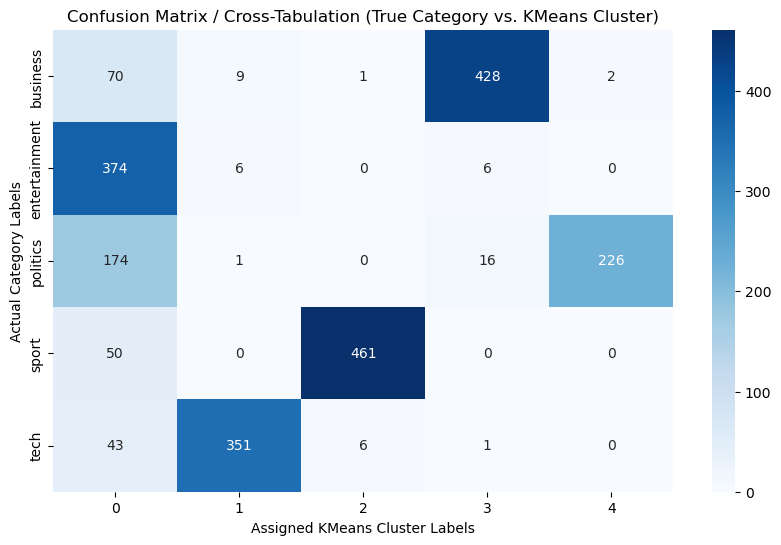

In [19]:
ari = adjusted_rand_score(true_labels, df['cluster_label'])
print(f"Adjusted Rand Index: {ari:.4f}")

crosstab = pd.crosstab(df['category'], df['cluster_label'])

print("\nCross-Tabulation of True Categories vs Assigned Clusters:")
display(crosstab)

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix / Cross-Tabulation (True Category vs. KMeans Cluster)")
plt.ylabel("Actual Category Labels")
plt.xlabel("Assigned KMeans Cluster Labels")
plt.show()

## Conclusion
Dans ce TP, nous avons appliqué l'algorithme de clustering **K-Means** sur un corpus textuel non étiqueté, après l'avoir transformé via la représentation **TF-IDF**. 

Grâce à la métrique de l'**Indice de Rand Ajusté (Adjusted Rand Index)** et à la matrice de confusion, nous avons pu évaluer dans quelle mesure les clusters formés non supervisés correspondent aux vraies catégories du jeu de données. Cela confirme que l'approche TF-IDF + K-Means est souvent un excellent point de départ pour grouper sémantiquement des documents textuels.